In [1]:
import pandas as pd
import numpy as np

In [19]:
cleaners_info = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
    "Age": [25, 30, 35, 40, 45],
    "Experience": [2, 5, 10, 15, 20],
    "Salary": [30000, 40000, 50000, 60000, 70000],
    "years_with_company": ["1-2", "3-5", "5-6", "8-9", "15-16"]
}

cleaners_df = pd.DataFrame(cleaners_info)
print(cleaners_df)

      Name  Age  Experience  Salary years_with_company
0    Alice   25           2   30000                1-2
1      Bob   30           5   40000                3-5
2  Charlie   35          10   50000                5-6
3    David   40          15   60000                8-9
4      Eve   45          20   70000              15-16


In [20]:
cleaners_df.describe()

,Age,Experience,Salary
count,5.000000,5.000000,5.000000
mean,35.000000,10.400000,50000.000000
std,7.905694,7.300685,15811.388301
min,25.000000,2.000000,30000.000000
25%,30.000000,5.000000,40000.000000
50%,35.000000,10.000000,50000.000000
75%,40.000000,15.000000,60000.000000
max,45.000000,20.000000,70000.000000


In [6]:
import matplotlib.pyplot as plt
# the same as 
#from matplotlib import pyplot as plt

In [12]:
# dir(plt)

#.plot is used to draw a line chart, you can also use sns for seaborn

In [11]:
# import seaborn as sns
# dir(sns)

{'whiskers': [<matplotlib.lines.Line2D at 0x1b65df77390>,
 'caps': [<matplotlib.lines.Line2D at 0x1b65df77610>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b65df77250>],
 'medians': [<matplotlib.lines.Line2D at 0x1b65df77890>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b65df779d0>],
 'means': []}

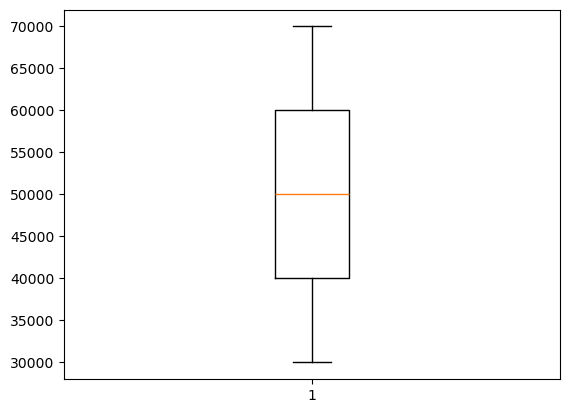

In [21]:
plt.boxplot(cleaners_df["Salary"])

<Axes: ylabel='Salary'>

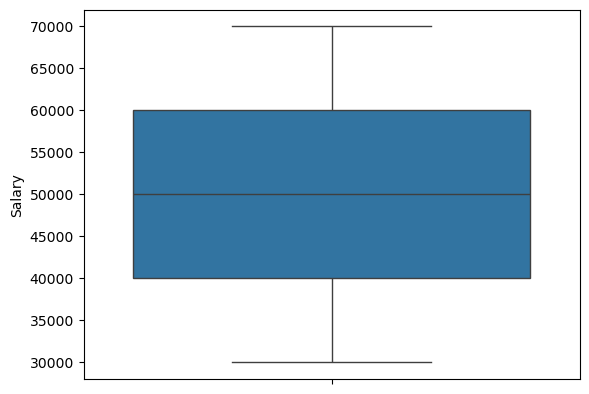

In [22]:
sns.boxplot(cleaners_df["Salary"])

In [28]:
cleaners_df

,Name,Age,Experience,Salary,years_with_company
0,Alice,25,2,NaN,1-2
1,Bob,30,5,40000.0,3-5
2,Charlie,35,10,50000.0,5-6
3,David,40,15,60000.0,8-9
4,Eve,45,20,70000.0,15-16


In [32]:
cleaners_df.iloc[0, 3] = 20000
cleaners_df.iloc[2, 3] = np.nan
cleaners_df.iloc[2, 4] = "1-2"
cleaners_df

,Name,Age,Experience,Salary,years_with_company
0,Alice,25,2,20000.0,1-2
1,Bob,30,5,40000.0,3-5
2,Charlie,35,10,NaN,1-2
3,David,40,15,60000.0,8-9
4,Eve,45,20,70000.0,15-16


In [33]:
df1 = cleaners_df.query("years_with_company == '1-2'")
df1

,Name,Age,Experience,Salary,years_with_company
0,Alice,25,2,20000.0,1-2
2,Charlie,35,10,NaN,1-2


In [35]:
mean_salary_0_1 = df1["Salary"].mean()
mean_salary_0_1

np.float64(20000.0)

In [36]:
cleaners_df["Salary"] = cleaners_df["Salary"].fillna(mean_salary_0_1)
cleaners_df

,Name,Age,Experience,Salary,years_with_company
0,Alice,25,2,20000.0,1-2
1,Bob,30,5,40000.0,3-5
2,Charlie,35,10,20000.0,1-2
3,David,40,15,60000.0,8-9
4,Eve,45,20,70000.0,15-16


### Probability thinking

What is the probability a student passes?

the mean gives this.

In [54]:
import pandas as pd

data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
    "hours_studied": [2, 3, 1, 1, 4],
    "attendance": [80, 90, 70, 60, 95],
    "previous_score": [70, 80, 45, 60, 85],
    "passed": [1, 1, 0, 0, 1]
}

df = pd.DataFrame(data)
print(df)

      Name  hours_studied  attendance  previous_score  passed
0    Alice              2          80              70       1
1      Bob              3          90              80       1
2  Charlie              1          70              45       0
3    David              1          60              60       0
4      Eve              4          95              85       1


In [39]:
df["passed"].mean()

np.float64(0.6)

Since the result is 0.6, that means 60% of the students passed.
This is called Empirical probability.


Empirical probability is basically trying to get a probability based on the data that you have.

#### Conditional probability (Very important for ML)

What is the probability a student passes if they study more than 6 hours?

there is a condition here.

In [49]:
df_mean_hrs_std = df["hours_studied"].mean()
print(f"Mean hours studied: {df_mean_hrs_std}")

# Mean gives us the average hours studied, but what if one student studied 40 hours?
# the average then becomes misleading, so we can use median instead which is the middle value when the data is sorted.

df_median_hrs_std = df["hours_studied"].median()
print(f"Median hours studied: {df_median_hrs_std}")

# Mean is affected by extreme values, Median is not affected by extreme values, it gives us a better representation of the central tendency of the data when there are outliers.

Mean hours studied: 2.2
Median hours studied: 2.0


In [55]:
df[df["hours_studied"] > 6]["passed"].mean()

nan

##### Variance and Standard Deviation

Do students study roughtly the same houror very  different amount of hours?

Standard deviation tells us how spread out study habis are.

**Interpretation**

Low standard deviation means students study similar hours. High stadard deviation means big differences between students study hours. 

In [50]:
df["hours_studied"].std()

1.3038404810405297

#### Binomial Distribution

Passing an exam has two outcomes.
- Pass
- Fail 

#this is a binary event

Binary events follow a binomial distibution.
- Pass/Fail
- Loan approved/rejected
- Fraud/not fraud
- Click/not click

This is why Logistic regression  is used for classification

##### Exercise
Compute:

- Average previous score
- Standard deviation of attendance
- probability a student studies more than 6 hours
- probability a student passes given attendance > 80%